# 나스닥(NASDAQ)과 코스피(KOSPI) 간의 상관관계 분석

## 주제
나스닥과 코스피 간의 상관관계를 분석하여, 두 주식 시장 간의 연관성을 이해하고 시각적으로 표현

## 목표
1. **상관관계 분석**: 코스피의 상승이 나스닥 지수와 어떤 상관관계가 있는지 확인
2. **시계열 분석**: 시간에 따라 나스닥과 코스피의 상관관계가 어떻게 변화하는지 파악
3. **시각화**: 상관관계와 시계열 분석 결과를 시각적으로 표현
4. **결론 도출**: 상관관계 분석 결과를 기반으로 두 지수 간의 관계를 해석하고, 그 의미를 도출

In [1]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install pandas_datareader
# !pip install yfinance
# !pip install scikit-learn
# !pip install torch torchvision torchaudio

In [2]:
# 주요 라이브러리
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
nasdaq = yf.download('^IXIC', start='2019-01-01', end='2024-09-01')
kospi = yf.download('^KS11', start='2019-01-01', end='2024-09-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
# 나스닥
display(nasdaq.head())
display(nasdaq.tail())

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-01-02,6506.910156,6693.709961,6506.879883,6665.939941,6665.939941,2261800000
2019-01-03,6584.770020,6600.209961,6457.129883,6463.500000,6463.500000,2631550000
2019-01-04,6567.140137,6760.689941,6554.240234,6738.859863,6738.859863,2596150000
2019-01-07,6757.529785,6855.600098,6741.399902,6823.470215,6823.470215,2523450000
2019-01-08,6893.439941,6909.580078,6795.859863,6897.000000,6897.000000,2407340000


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-08-26,17867.849609,17909.089844,17645.689453,17725.769531,17725.769531,5110940000
2024-08-27,17655.519531,17789.720703,17573.369141,17754.820312,17754.820312,4362380000
2024-08-28,17738.800781,17759.939453,17439.400391,17556.029297,17556.029297,5211920000
2024-08-29,17610.570312,17789.210938,17482.599609,17516.429688,17516.429688,5727780000
2024-08-30,17650.490234,17720.380859,17498.789062,17713.619141,17713.619141,5531150000


In [5]:
# 코스피
display(kospi.head())
display(kospi.tail())

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-01-02,2050.550049,2053.449951,2004.270020,2010.000000,2010.000000,326400
2019-01-03,2011.810059,2014.719971,1991.650024,1993.699951,1993.699951,428000
2019-01-04,1992.400024,2011.560059,1984.530029,2010.250000,2010.250000,409000
2019-01-07,2034.239990,2048.060059,2030.900024,2037.099976,2037.099976,440200
2019-01-08,2038.680054,2042.699951,2023.589966,2025.270020,2025.270020,397800


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-08-26,2716.879883,2718.469971,2688.790039,2698.010010,2698.010010,333700
2024-08-27,2696.239990,2700.179932,2681.919922,2689.250000,2689.250000,264100
2024-08-28,2690.590088,2695.510010,2671.590088,2689.830078,2689.830078,280800
2024-08-29,2657.179932,2672.899902,2649.560059,2662.280029,2662.280029,288800
2024-08-30,2676.719971,2686.510010,2668.659912,2674.310059,2674.310059,278800


In [6]:
kospi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1396 entries, 2019-01-02 to 2024-08-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1396 non-null   float64
 1   High       1396 non-null   float64
 2   Low        1396 non-null   float64
 3   Close      1396 non-null   float64
 4   Adj Close  1396 non-null   float64
 5   Volume     1396 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 76.3 KB


In [7]:
nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1426 entries, 2019-01-02 to 2024-08-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1426 non-null   float64
 1   High       1426 non-null   float64
 2   Low        1426 non-null   float64
 3   Close      1426 non-null   float64
 4   Adj Close  1426 non-null   float64
 5   Volume     1426 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 78.0 KB


In [8]:
nasdaq['Returns'] = nasdaq['Close'].pct_change()
kospi['Returns'] = kospi['Close'].pct_change()

In [9]:
kospi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1396 entries, 2019-01-02 to 2024-08-30
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1396 non-null   float64
 1   High       1396 non-null   float64
 2   Low        1396 non-null   float64
 3   Close      1396 non-null   float64
 4   Adj Close  1396 non-null   float64
 5   Volume     1396 non-null   int64  
 6   Returns    1395 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 87.2 KB


In [10]:
nasdaq.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1426 entries, 2019-01-02 to 2024-08-30
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1426 non-null   float64
 1   High       1426 non-null   float64
 2   Low        1426 non-null   float64
 3   Close      1426 non-null   float64
 4   Adj Close  1426 non-null   float64
 5   Volume     1426 non-null   int64  
 6   Returns    1425 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 89.1 KB


In [11]:
# 나스닥
display(nasdaq.head())
display(nasdaq.tail())

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2019-01-02,6506.910156,6693.709961,6506.879883,6665.939941,6665.939941,2261800000,NaN
2019-01-03,6584.770020,6600.209961,6457.129883,6463.500000,6463.500000,2631550000,-0.030369
2019-01-04,6567.140137,6760.689941,6554.240234,6738.859863,6738.859863,2596150000,0.042602
2019-01-07,6757.529785,6855.600098,6741.399902,6823.470215,6823.470215,2523450000,0.012556
2019-01-08,6893.439941,6909.580078,6795.859863,6897.000000,6897.000000,2407340000,0.010776


,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2024-08-26,17867.849609,17909.089844,17645.689453,17725.769531,17725.769531,5110940000,-0.008503
2024-08-27,17655.519531,17789.720703,17573.369141,17754.820312,17754.820312,4362380000,0.001639
2024-08-28,17738.800781,17759.939453,17439.400391,17556.029297,17556.029297,5211920000,-0.011196
2024-08-29,17610.570312,17789.210938,17482.599609,17516.429688,17516.429688,5727780000,-0.002256
2024-08-30,17650.490234,17720.380859,17498.789062,17713.619141,17713.619141,5531150000,0.011257


In [12]:
# 코스피
display(kospi.head())
display(kospi.tail())

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2019-01-02,2050.550049,2053.449951,2004.270020,2010.000000,2010.000000,326400,NaN
2019-01-03,2011.810059,2014.719971,1991.650024,1993.699951,1993.699951,428000,-0.008109
2019-01-04,1992.400024,2011.560059,1984.530029,2010.250000,2010.250000,409000,0.008301
2019-01-07,2034.239990,2048.060059,2030.900024,2037.099976,2037.099976,440200,0.013357
2019-01-08,2038.680054,2042.699951,2023.589966,2025.270020,2025.270020,397800,-0.005807


,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2024-08-26,2716.879883,2718.469971,2688.790039,2698.010010,2698.010010,333700,-0.001362
2024-08-27,2696.239990,2700.179932,2681.919922,2689.250000,2689.250000,264100,-0.003247
2024-08-28,2690.590088,2695.510010,2671.590088,2689.830078,2689.830078,280800,0.000216
2024-08-29,2657.179932,2672.899902,2649.560059,2662.280029,2662.280029,288800,-0.010242
2024-08-30,2676.719971,2686.510010,2668.659912,2674.310059,2674.310059,278800,0.004519


In [13]:
kospi=kospi.dropna()
display(kospi.head())

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2019-01-03,2011.810059,2014.719971,1991.650024,1993.699951,1993.699951,428000,-0.008109
2019-01-04,1992.400024,2011.560059,1984.530029,2010.250000,2010.250000,409000,0.008301
2019-01-07,2034.239990,2048.060059,2030.900024,2037.099976,2037.099976,440200,0.013357
2019-01-08,2038.680054,2042.699951,2023.589966,2025.270020,2025.270020,397800,-0.005807
2019-01-09,2034.189941,2068.229980,2034.189941,2064.709961,2064.709961,386200,0.019474


In [14]:
nasdaq = nasdaq.dropna()
display(nasdaq.head())

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2019-01-03,6584.770020,6600.209961,6457.129883,6463.500000,6463.500000,2631550000,-0.030369
2019-01-04,6567.140137,6760.689941,6554.240234,6738.859863,6738.859863,2596150000,0.042602
2019-01-07,6757.529785,6855.600098,6741.399902,6823.470215,6823.470215,2523450000,0.012556
2019-01-08,6893.439941,6909.580078,6795.859863,6897.000000,6897.000000,2407340000,0.010776
2019-01-09,6923.060059,6985.220215,6899.560059,6957.080078,6957.080078,2434500000,0.008711


In [15]:
returns_data = pd.merge(nasdaq['Returns'], kospi['Returns'], left_index=True, right_index=True, suffixes=('_NASDAQ', '_KOSPI'))

In [16]:
display(returns_data.head())
display(returns_data.tail())

,Returns_NASDAQ,Returns_KOSPI
Date,,
2019-01-03,-0.030369,-0.008109
2019-01-04,0.042602,0.008301
2019-01-07,0.012556,0.013357
2019-01-08,0.010776,-0.005807
2019-01-09,0.008711,0.019474


,Returns_NASDAQ,Returns_KOSPI
Date,,
2024-08-26,-0.008503,-0.001362
2024-08-27,0.001639,-0.003247
2024-08-28,-0.011196,0.000216
2024-08-29,-0.002256,-0.010242
2024-08-30,0.011257,0.004519


In [17]:
kospi.describe()

,Open,High,Low,Close,Adj Close,Volume,Returns
count,1395.000000,1395.000000,1395.000000,1395.000000,1395.000000,1.395000e+03,1395.000000
mean,2515.734557,2529.227878,2499.145135,2514.345835,2514.345835,6.851071e+05,0.000278
std,370.450158,371.448684,369.107801,370.046511,370.046511,3.406242e+05,0.012065
min,1474.449951,1516.750000,1439.430054,1457.640015,1457.640015,2.575000e+05,-0.087677
25%,2209.199951,2220.055054,2195.119995,2209.129883,2209.129883,4.469000e+05,-0.006175
50%,2487.350098,2498.540039,2472.449951,2486.669922,2486.669922,5.865000e+05,0.000732
75%,2730.270020,2743.175049,2712.430054,2729.829956,2729.829956,8.187500e+05,0.007062
max,3305.459961,3316.080078,3295.439941,3305.209961,3305.209961,3.455500e+06,0.086012


In [18]:
nasdaq.describe()

,Open,High,Low,Close,Adj Close,Volume,Returns
count,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1.425000e+03,1425.000000
mean,12130.053165,12219.118824,12034.044579,12132.671687,12132.671687,4.389050e+09,0.000805
std,2877.651589,2889.253083,2860.283586,2874.575848,2874.575848,1.452603e+09,0.015390
min,6567.140137,6600.209961,6457.129883,6463.500000,6463.500000,1.014530e+09,-0.123213
25%,9708.009766,9756.070312,9650.019531,9726.019531,9726.019531,3.706990e+09,-0.006310
50%,12234.559570,12320.120117,12174.059570,12256.919922,12256.919922,4.530190e+09,0.001329
75%,14204.509766,14289.200195,14121.000000,14204.169922,14204.169922,5.183560e+09,0.009049
max,18659.250000,18671.070312,18467.580078,18647.449219,18647.449219,1.193260e+10,0.093460


In [19]:
corr, _ = pearsonr(returns_data['Returns_NASDAQ'], returns_data['Returns_KOSPI'])
print(f"상관계수: {corr:.4f}")

상관계수: 0.1935


## 피어슨 상관계수 해석

분석 결과, 나스닥(NASDAQ)과 코스피(KOSPI) 지수 간의 피어슨 상관계수는 **양수**로 확인 가능 이는 두 지수 간에 **양의 상관관계**가 존재함을 의미 즉, 나스닥 지수가 상승할 때 코스피 지수도 함께 상승하는 경향이 있음

그러나, 상관계수의 절대값이 작아 **약한 양의 상관관계**를 보이므로, 두 지수 간의 관계가 존재하긴 하지만 **크게 영향을 끼치지 않는 수준**

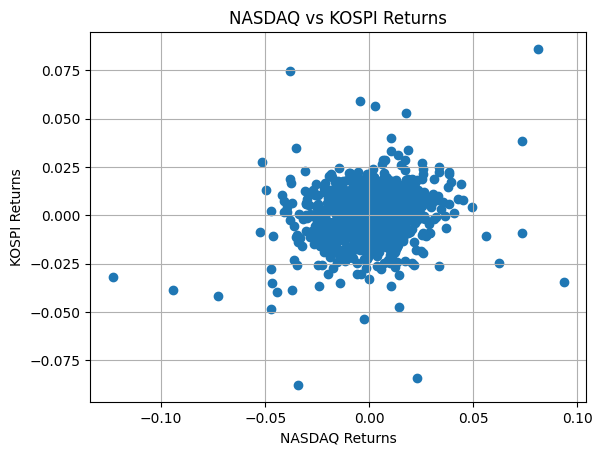

In [20]:
plt.scatter(returns_data['Returns_NASDAQ'], returns_data['Returns_KOSPI'])
plt.title('NASDAQ vs KOSPI Returns')
plt.xlabel('NASDAQ Returns')
plt.ylabel('KOSPI Returns')
plt.grid(True)
plt.show()

## 산점도 해석

산점도를 통해 나스닥(NASDAQ) 지수와 코스피(KOSPI) 지수의 수익률 간의 관계를 시각적으로 확인 점들이 대각선 상향으로 어느 정도 모여 있는 것은 두 지수 간에 **양의 상관관계**가 있음

그러나, 점들이 비교적 널리 퍼져 있어 **약한 양의 상관관계**로 확인 이는 피어슨 상관계수의 해석과도 일치

## 결론

두 지수 간에 관계가 존재하긴 하지만 그 관계가 강하지 않아 하나의 지수가 다른 지수에 미치는 영향이 크지 않음